In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df.head()
df.info()
df.isnull().sum()
df.describe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

<bound method NDFrame.describe of      Applicant_ID  Applicant_Income  Coapplicant_Income Employment_Status  \
0             1.0           17795.0              1387.0          Salaried   
1             2.0            2860.0              2679.0          Salaried   
2             3.0            7390.0              2106.0          Salaried   
3             4.0           13964.0              8173.0          Salaried   
4             5.0           13284.0              4223.0     Self-employed   
..            ...               ...                 ...               ...   
995         996.0               NaN              9092.0          Salaried   
996         997.0            3279.0              6356.0     Self-employed   
997         998.0           15192.0              8433.0          Contract   
998         999.0            9083.0              7380.0        Unemployed   
999        1000.0           13093.0              2385.0          Salaried   

      Age Marital_Status  Dependents  Cre

# Handle Missing Values

In [4]:
categorical_cols = df.select_dtypes(include = ["object"]).columns
#numerical_cols = df.select_dtypes(include = ["float64"]).columns
numerical_cols = df.select_dtypes(include = ["number"]).columns

In [5]:
categorical_cols
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [6]:
categorical_cols.size + numerical_cols.size

20

In [7]:
# Simple Imputer for completing missing values with simple strategies:-

from sklearn.impute import SimpleImputer
# Create Numerical_imputer:-
num_imp = SimpleImputer(strategy="mean")
# Apply Numerical _imputer:-
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [8]:
df.isnull().sum()

Applicant_ID           0
Applicant_Income       0
Coapplicant_Income     0
Employment_Status     50
Age                    0
Marital_Status        50
Dependents             0
Credit_Score           0
Existing_Loans         0
DTI_Ratio              0
Savings                0
Collateral_Value       0
Loan_Amount            0
Loan_Term              0
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [9]:
# Create categorical_imputer:-
cat_imp = SimpleImputer(strategy="most_frequent")
# Apply categorical _imputer:-
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [10]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA - Exploratory data analysis

In [11]:
# How balance our classes are:-

df["Loan_Approved"].value_counts()


Loan_Approved
No     702
Yes    298
Name: count, dtype: int64

Text(0.5, 1.0, 'Is Loan approved or not')

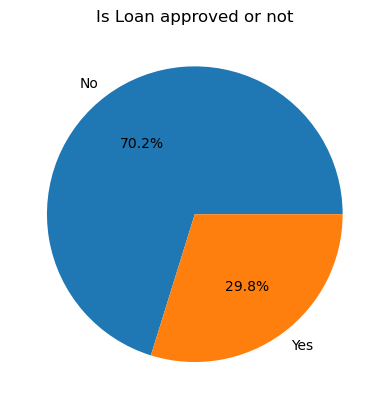

In [12]:
classes_cnt = df["Loan_Approved"].value_counts()
plt.pie(classes_cnt, labels = ["No","Yes"] ,autopct = "%1.1f%%")
plt.title("Is Loan approved or not")

In [13]:
# Analyze Categorical columns :-

df["Gender"].value_counts()

Gender
Male      621
Female    379
Name: count, dtype: int64

In [14]:
gender_cnt = df["Gender"].value_counts()
type(gender_cnt)

pandas.core.series.Series

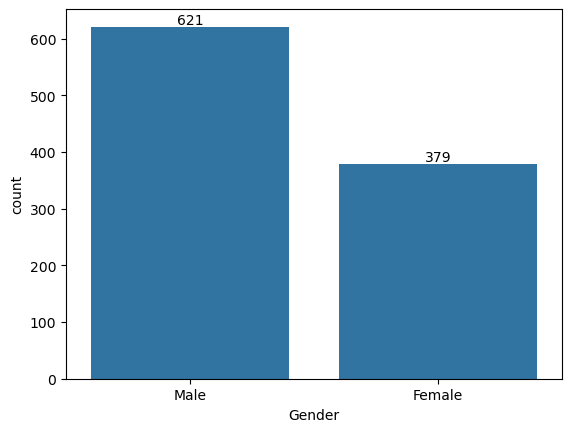

[<BarContainer object of 2 artists>]

In [15]:
ax = sns.barplot(gender_cnt)
for container in ax.containers:
    ax.bar_label(container)
plt.show()
ax.containers

In [16]:
# Analyze Categories:-
df["Education_Level"].value_counts()

Education_Level
Graduate        722
Not Graduate    278
Name: count, dtype: int64

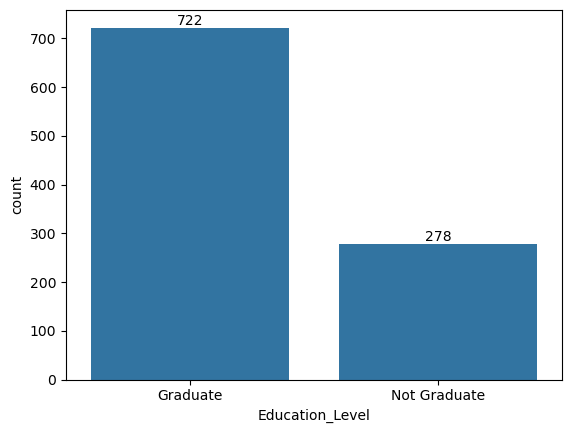

[<BarContainer object of 2 artists>]

In [17]:
edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
for container in ax.containers:
    ax.bar_label(container)
plt.show()
ax.containers

In [18]:
df["Loan_Purpose"].value_counts()

Loan_Purpose
Business     252
Car          199
Home         190
Education    181
Personal     178
Name: count, dtype: int64

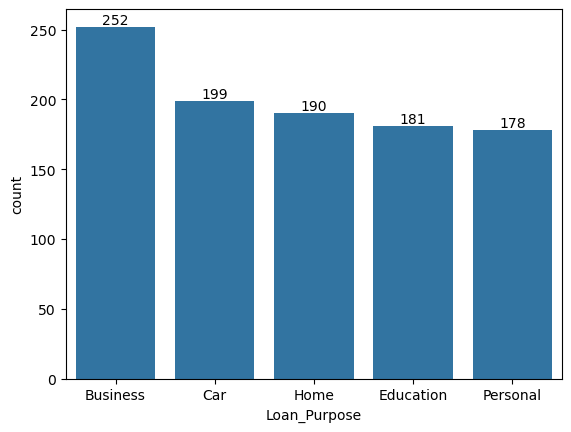

[<BarContainer object of 5 artists>]

In [19]:
ln_pur_cnt = df["Loan_Purpose"].value_counts()
ax = sns.barplot(ln_pur_cnt)
for container in ax.containers:
    ax.bar_label(container)
plt.show()
ax.containers

In [20]:
df["Property_Area"].value_counts()

Property_Area
Urban        517
Rural        294
Semiurban    189
Name: count, dtype: int64

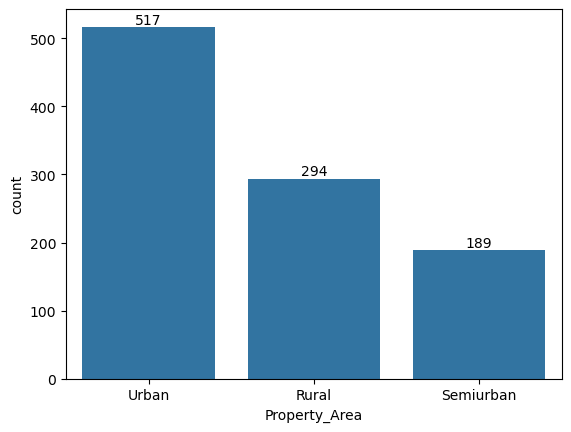

[<BarContainer object of 3 artists>]

In [21]:
pr_area_cnt = df["Property_Area"].value_counts()
ax = sns.barplot(pr_area_cnt)
for container in ax.containers:
    ax.bar_label(container)
plt.show()
ax.containers

In [22]:
df["Employer_Category"].value_counts()

Employer_Category
Private       422
Government    202
MNC           144
Business      135
Unemployed     97
Name: count, dtype: int64

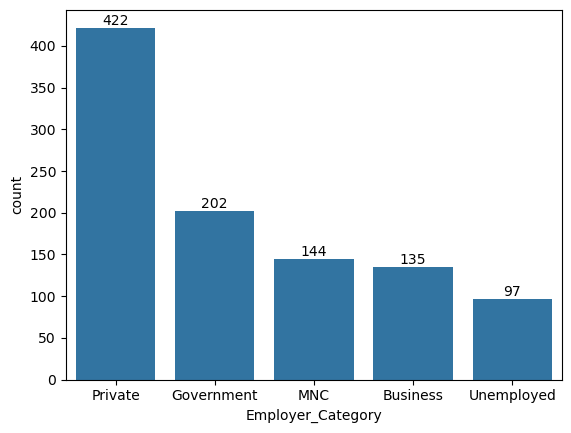

[<BarContainer object of 5 artists>]

In [23]:
em_cat_cnt = df["Employer_Category"].value_counts()
ax = sns.barplot(em_cat_cnt)
for container in ax.containers:
    ax.bar_label(container)
plt.show()
ax.containers

In [24]:
df["Employment_Status"].value_counts()

Employment_Status
Salaried         515
Contract         213
Self-employed    182
Unemployed        90
Name: count, dtype: int64

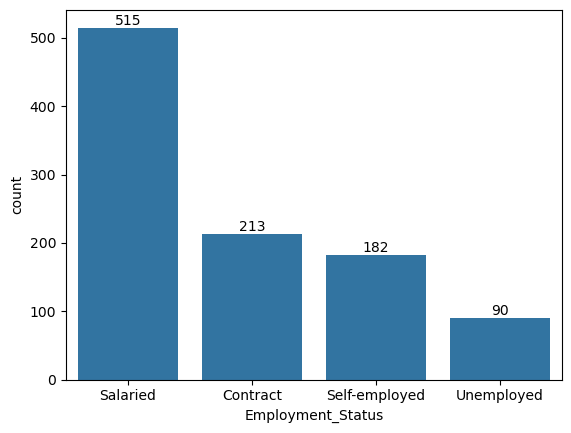

[<BarContainer object of 4 artists>]

In [25]:
em_sta_cnt = df["Employment_Status"].value_counts()
ax = sns.barplot(em_sta_cnt)
for container in ax.containers:
    ax.bar_label(container)
plt.show()
ax.containers

Applicant_Income
10852.571579    50
19568.000000     2
8371.000000      2
12789.000000     2
9970.000000      2
                ..
7949.000000      1
3150.000000      1
3931.000000      1
11204.000000     1
9083.000000      1
Name: count, Length: 925, dtype: int64

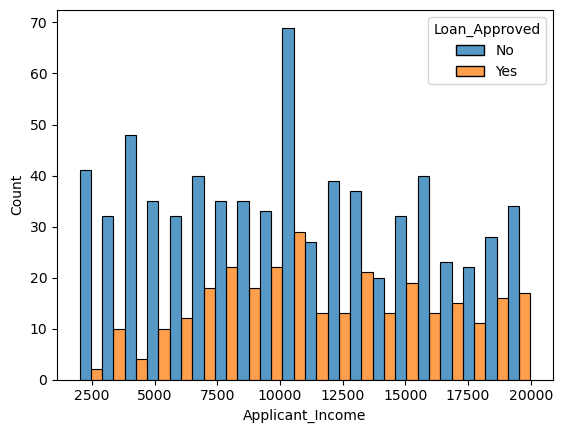

In [26]:
# analyze income: Applicant_Income

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20,
    hue = "Loan_Approved",
    multiple = "dodge" 
    
)
df["Applicant_Income"].value_counts()

Coapplicant_Income
5082.455789    50
3610.000000     3
7979.000000     2
2719.000000     2
2817.000000     2
               ..
6353.000000     1
2353.000000     1
7437.000000     1
4799.000000     1
2385.000000     1
Name: count, Length: 903, dtype: int64

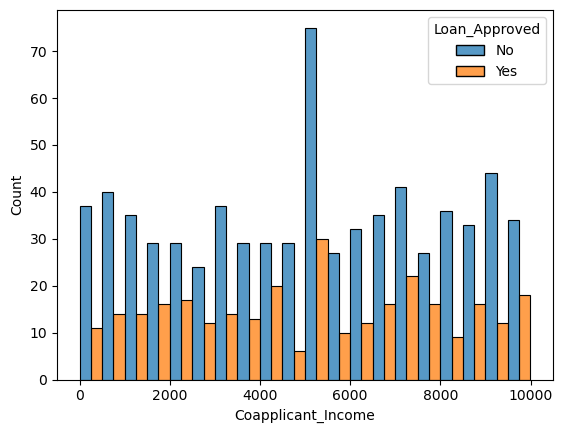

In [27]:
# analyze income: Coapplicant_Income
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20,
     hue = "Loan_Approved",
     multiple = "dodge"
    
)
df["Coapplicant_Income"].value_counts()

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

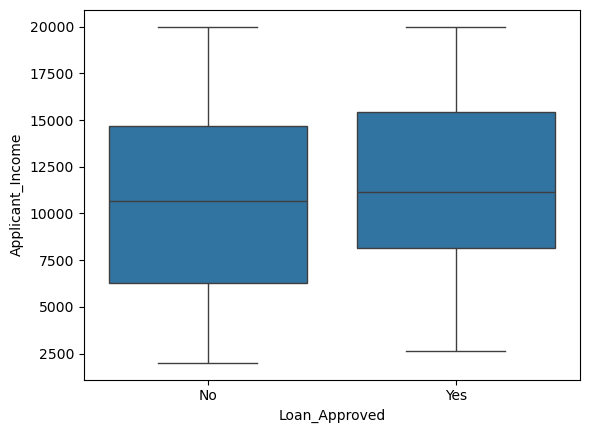

In [28]:
# outliers - box plot

sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

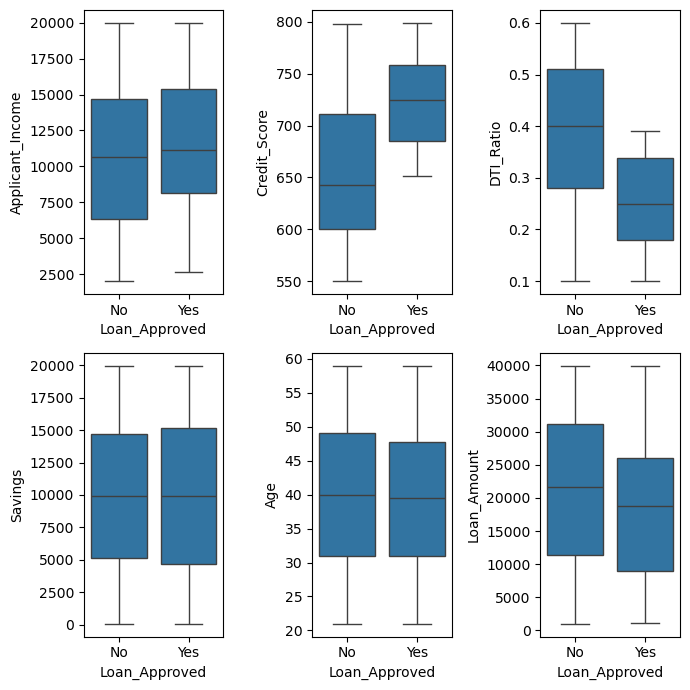

In [29]:
# outliers - box plots:-

fig,ax = plt.subplots(2,3, figsize = (7,7))
sns.boxplot(ax = ax[0][0],data = df,x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = ax[0][1],data = df,x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = ax[0][2],data = df,x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax = ax[1][0],data = df,x = "Loan_Approved",y = "Savings")
sns.boxplot(ax = ax[1][1],data = df,x = "Loan_Approved",y = "Age")
sns.boxplot(ax = ax[1][2],data = df,x = "Loan_Approved",y = "Loan_Amount")

fig.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

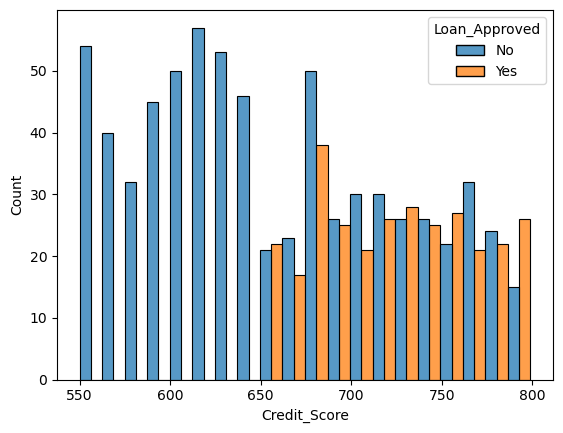

In [30]:
# Credit_Score with loan Approval:-

sns.histplot(
    data = df,
    x = "Credit_Score",
    bins = 20,
     hue = "Loan_Approved",
     multiple = "dodge"
    
)

In [31]:
# Remove applicant Id:-
df = df.drop("Applicant_ID", axis = 1)


In [32]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [33]:
# Feature Encoding :-

# Label encoding:-

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
df.info()


le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [34]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [35]:
# One hot encoding:-
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area","Gender", "Employer_Category"]

ohe =OneHotEncoder(drop ="first",sparse_output = False, handle_unknown = "ignore")

encoded_array = ohe.fit_transform(df[cols]) # Return 2d array


In [36]:
encoded_array 

array([[1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]], shape=(1000, 15))

In [37]:
# Now, convert 2D array  to dataframe:- 

ohe.get_feature_names_out(cols)
df.index
encoded_df = pd.DataFrame(encoded_array,columns = ohe.get_feature_names_out(cols), index = df.index)

In [38]:
encoded_df.head()

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [39]:
# Now , append to the original Dataframe:-
df_new = pd.concat([df.drop(cols,axis = 1 ), encoded_df], axis = 1)

In [40]:
df_new.head()
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation Heatmap

In [41]:
# Create numerical columns:-

num_cols = df_new.select_dtypes(include = "number")

In [42]:
num_cols

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
997,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
998,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [43]:
# Now, create correlation matrix:-
corr_matrix = num_cols.corr()

In [44]:
type(corr_matrix)
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,-0.006283,0.029865,0.037293,0.003100,-0.025661,0.048402,-0.066041,0.021232,-0.012960,0.072462
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.044642,0.027343,-0.005785,-0.032278,0.024082,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.000897,0.035760,-0.013464,-0.014480,-0.009655
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,-0.006119,-0.000930,0.032498,0.040206,-0.050076,0.103456,0.013108,-0.025975,0.013923,-0.026566


In [45]:
corr_matrix["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

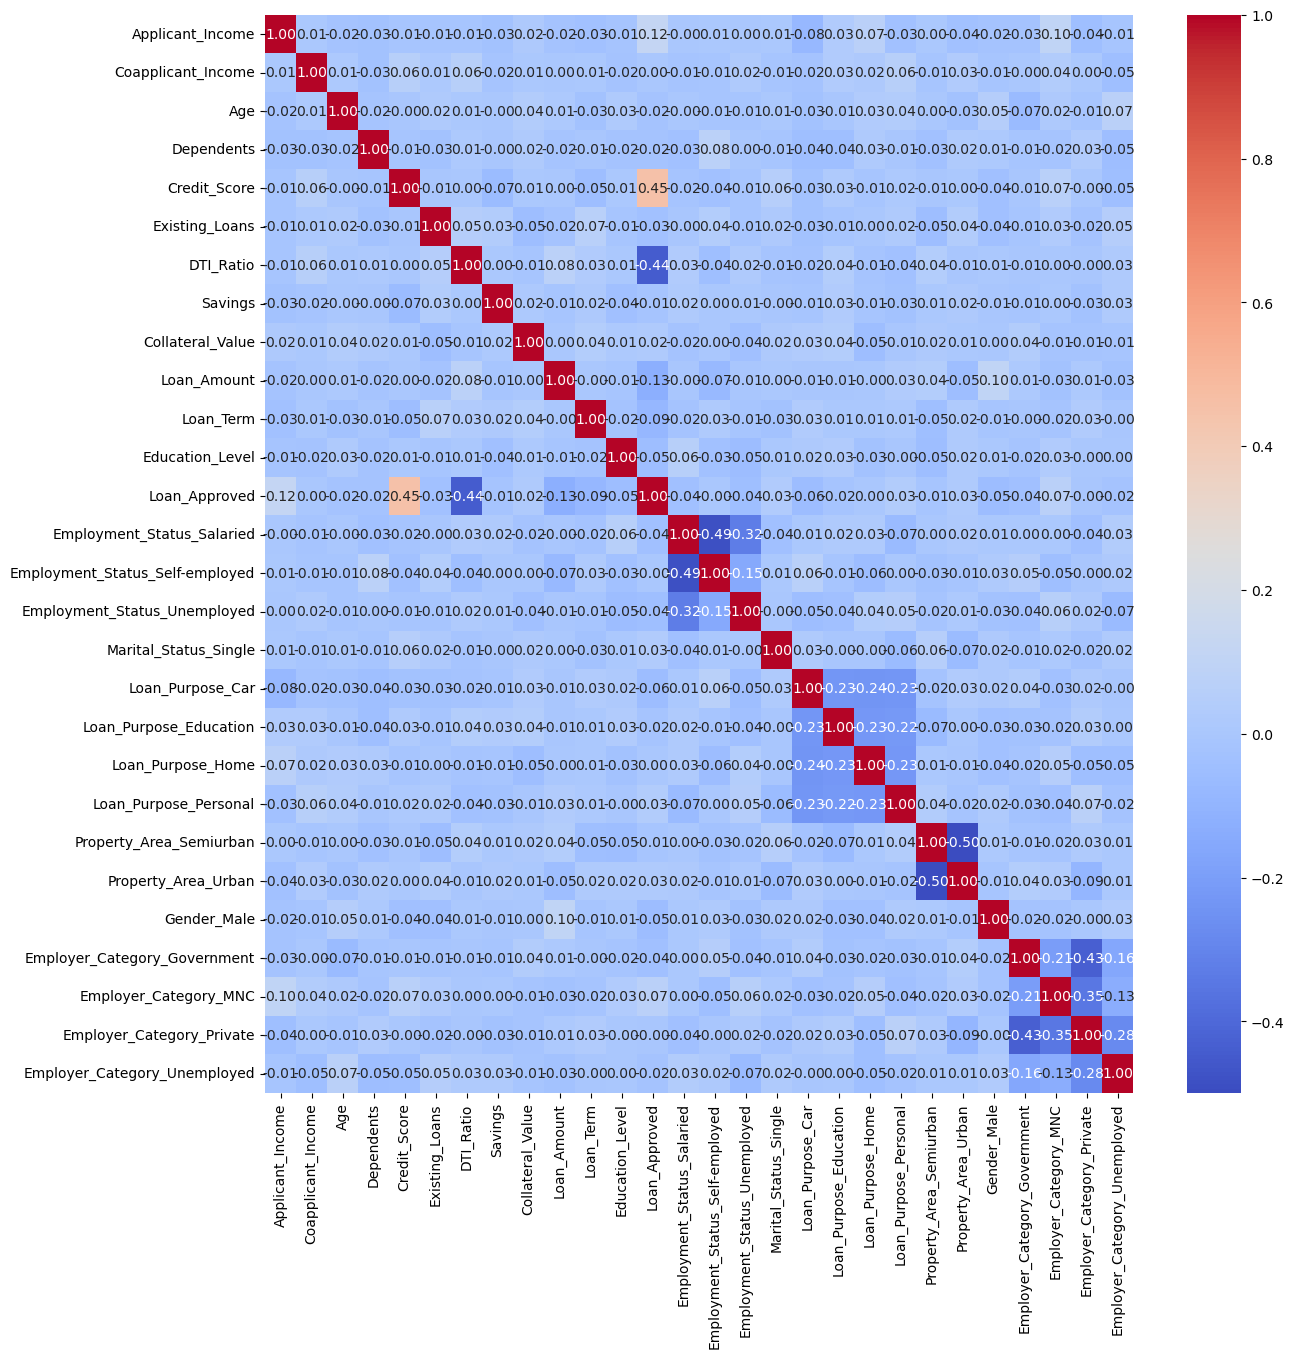

In [46]:
# Now , Create Heatmap :

plt.figure(figsize = (14,14))
sns.heatmap(
    corr_matrix,
    annot =True,
    fmt = ".2f",
    cmap = "coolwarm"
)


# Train_Test_Split + Feature Scaling

In [47]:
X = df_new.drop("Loan_Approved",axis = 1)
y = df_new["Loan_Approved"]

In [48]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [49]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42 )

In [51]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
X_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
         2.41611400e+00, -8.59726954e-01, -3.07231582e-01]],
      shape=(800, 27))

# Train & Evaluate Models

In [54]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [55]:
y_pred = log_model.predict(X_test_scaled)

In [56]:
# Evaluation:- 
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
print("Logistic Regression Model")
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("f1_score :", f1_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("confusion_matrix :", confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision : 0.7833333333333333
Recall : 0.7704918032786885
f1_score : 0.7768595041322314
Accuracy : 0.865
confusion_matrix : [[126  13]
 [ 14  47]]


In [57]:
# KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

knn_model = KNeighborsClassifier(n_neighbors =5)
knn_model.fit(X_train_scaled,y_train)

y_pred = knn_model.predict(X_test_scaled)

print("KNN Model")
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("f1_score :", f1_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("confusion_matrix :", confusion_matrix(y_test, y_pred))

KNN Model
Precision : 0.6274509803921569
Recall : 0.5245901639344263
f1_score : 0.5714285714285714
Accuracy : 0.76
confusion_matrix : [[120  19]
 [ 29  32]]


In [58]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled,y_train)

y_pred = gnb_model.predict(X_test_scaled)

print("Naive Bayes Model")
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("f1_score :", f1_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("confusion_matrix :", confusion_matrix(y_test, y_pred))

Naive Bayes Model
Precision : 0.8035714285714286
Recall : 0.7377049180327869
f1_score : 0.7692307692307693
Accuracy : 0.865
confusion_matrix : [[128  11]
 [ 16  45]]


# Best Model on the basis of Precision ==> Naive Bayes

# Feature Engineering

In [59]:
# Add & Transform features
import numpy as np
df_new["DTI_Ratio_sq"] = df_new["DTI_Ratio"]**2
df_new["Credit_Score_sq"] = df_new["Credit_Score"]**2

# SKEWED VALUES IN DATASET:-
df_new["Applicant_Income_log"] = np.log1p(df_new["Applicant_Income"])

X =  df_new.drop(columns =["Loan_Approved","Credit_Score", "DTI_Ratio", "Applicant_Income"])
y = df_new["Loan_Approved"]

# Train_Test_Split:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42 )

# Scaling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
X_train.head()

,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,Employment_Status_Salaried,...,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq,Applicant_Income_log
29,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0121,363609.000000,8.681181
535,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0441,376996.000000,8.472196
695,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0484,341056.000000,9.292249
557,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.1156,527076.000000,7.776954
836,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0324,457021.542187,8.561975


In [61]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)
y_pred = log_model.predict(X_test_scaled)
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
print("Logistic Regression Model")
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("f1_score :", f1_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("confusion_matrix :", confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision : 0.7777777777777778
Recall : 0.8032786885245902
f1_score : 0.7903225806451613
Accuracy : 0.87
confusion_matrix : [[125  14]
 [ 12  49]]


In [62]:
# KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

knn_model = KNeighborsClassifier(n_neighbors =5)
knn_model.fit(X_train_scaled,y_train)

y_pred = knn_model.predict(X_test_scaled)

print("KNN Model")
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("f1_score :", f1_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("confusion_matrix :", confusion_matrix(y_test, y_pred))

KNN Model
Precision : 0.6296296296296297
Recall : 0.5573770491803278
f1_score : 0.591304347826087
Accuracy : 0.765
confusion_matrix : [[119  20]
 [ 27  34]]


In [63]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled,y_train)

y_pred = gnb_model.predict(X_test_scaled)

print("Naive Bayes Model")
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("f1_score :", f1_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("confusion_matrix :", confusion_matrix(y_test, y_pred))

Naive Bayes Model
Precision : 0.8035714285714286
Recall : 0.7377049180327869
f1_score : 0.7692307692307693
Accuracy : 0.865
confusion_matrix : [[128  11]
 [ 16  45]]


In [64]:
#  PLOYNOMIAL FEATURES:-

# from sklearn.preprocessing import PolynomialFeatures
# # Sample data with 2 features
# X = np.array([[2, 3], 
#               [4, 5]])
# # Create polynomial features of degree 2
# poly = PolynomialFeatures(degree=2, include_bias=True)
# X_poly = poly.fit_transform(X)
# print(X_poly)




# SKEWED VALUES IN DATASET:-

# np.log1p(x) is a NumPy function that calculates the mathematical operation
# ln(1 + x) element-wise for an input array or scalar.It is designed to solve
# two specific problems encountered when working with standard logarithms.
# Why use np.log1p instead of np.log(x + 1)?1. 
# Preventing Mathematical Errors from Zero ValuesThe standard natural logarithm \(\ln(0)\)
# is mathematically undefined and evaluates to negative infinity (-inf) in Python. 
# Real-world data (such as web traffic, store sales, or text token frequencies)
# frequently contains explicit 0 values. By automatically shifting the data by +1, np.log1p(0)
# safely evaluates to 0 instead of breaking your calculations or returning -inf.2.
# High Floating-Point Accuracy for Tiny NumbersFor extremely small values of x (e.g., 10⁻¹⁵),
# computers encounter rounding errors when executing 1 + x because
# floating-point precision cannot accurately keep track of both numbers simultaneously.
# np.log1p bypasses this intermediate addition step entirely using specialized low-level C libraries,
# delivering precise results for values near zero.

# Best Model on the basis of Precision ==> Naive Bayes